<a href="https://colab.research.google.com/github/punsatya04/Satya_INFO4670_Spring2026/blob/main/Logistic_Regression_Car_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 11: Assignment 4 - Logistic Regression Assignment (Age & Salary → Purchased)
**Coures:** INFO 4670 Fengjiao Tu  
**Goal:** Train and evaluate a Logistic Regression model to predict whether a customer purchases a car using `Age` and `Salary`.

---

## I. Assignment Objective
By completing this assignment, you will:
- Understand the concept and intuition of logistic regression.
- Load and preprocess data using `pandas`.
- Train and evaluate a logistic regression model with `scikit-learn`.
- Visualize classification results.
- Analyze model performance and reflect on possible improvements.


## II. Dataset Description
Expected CSV file name: **`car_purchase_data.csv`**

| Column | Description | Example |
|--------|-------------|---------|
| `Age` | Age of the customer | 35 |
| `Salary` | Annual or monthly income | 60000 |
| `Purchased` | Whether the customer purchased a car (1 = Yes, 0 = No) | 1 |


In [5]:
from google.colab import files
uploaded = files.upload()

Saving car_purchase_data.csv to car_purchase_data (1).csv


---
# Grading Rubric (Total = 100 points)

| Section | Description | Points | Details |
|--------|-------------|--------|---------|
| **Objective Understanding** | Explain purpose and logic of logistic regression | 10 | Goal & rationale (5); why LR for this task (5) |
| **Data Preparation** | Data loading, splitting, scaling | 20 | Import & preview (5); X/y split (5); train/test (5); scaling (5) |
| ** Model Training & Evaluation** | Fit, predict, metrics, visualization | 40 | Trained correctly (10); metrics shown (10); **accuracy ≥ 87.5% (10)**; visualization (10) |
| ** Analysis & Reflection** | Interpretation and critical thinking | 30 | Probability→class explanation (10); result discussion (10); improvements (10) |


**Accuracy Requirement:**
- Full credit (10 pts) if **accuracy ≥ 87.5%**
- Partial (7–9 pts) if **80% ≤ accuracy < 87.5%**
- Minimal (≤5 pts) if **accuracy < 80%**
- 0 pts if the model fails to run


## III. Steps to Complete
Follow the cells below in order. According to the hands-on task, please complete the code.

### Step 1: Import libraries and load data

In [6]:
#Please write the code here

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("car_purchase_data.csv")
df.head()


,User ID,Gender,Age,Salary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


### Step 2: Split features and target

In [7]:
#Please write the code here
X = df[['Age', 'Salary']]
y = df['Purchased']

print(X.head())
print(y.head())


   Age  Salary
0   19   19000
1   35   20000
2   26   43000
3   27   57000
4   19   76000
0    0
1    0
2    0
3    0
4    0
Name: Purchased, dtype: int64


### Step 3: Train/Test Split

In [8]:
#Please write the code here
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

print(X_train.shape)
print(X_test.shape)


(300, 2)
(100, 2)


### Step 4: Feature Scaling

In [9]:
#Please write the code here
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

print(X_train[:5])
print(X_test[:5])


[[ 0.58164944 -0.88670699]
 [-0.60673761  1.46173768]
 [-0.01254409 -0.5677824 ]
 [-0.60673761  1.89663484]
 [ 1.37390747 -1.40858358]]
[[-0.80480212  0.50496393]
 [-0.01254409 -0.5677824 ]
 [-0.30964085  0.1570462 ]
 [-0.80480212  0.27301877]
 [-0.30964085 -0.5677824 ]]


### Step 5: Train Logistic Regression Model

In [10]:
#Please write the code here
model = LogisticRegression(random_state=0)
model.fit(X_train, y_train)


LogisticRegression(random_state=0)

### Step 6: Predict and Evaluate

In [11]:
#Please write the code here
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Predictions:
[0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0
 0 0 1 0 1 1 1 1 0 0 1 1 0 1 0 0 0 1 0 0 0 0 0 0 1 1]
Confusion Matrix:
[[65  3]
 [ 8 24]]
Accuracy: 0.89
Accuracy (%): 89.0


### Step 7: Visualization of Decision Regions

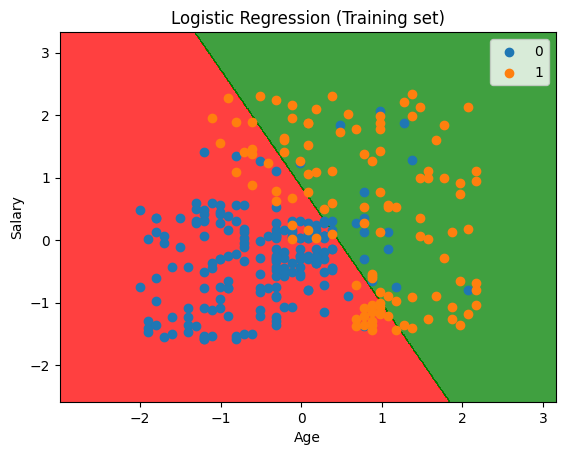

In [12]:
#Please write the code here
from matplotlib.colors import ListedColormap

X_set, y_set = X_train, y_train.values

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
)

plt.contourf(
    X1, X2,
    model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75,
    cmap=ListedColormap(('red', 'green'))
)

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        label=j
    )

plt.title('Logistic Regression (Training set)')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.legend()
plt.show()

## IV. Reflection Questions
1. Logistic regression outputs probabilities — why can it still be used for classification?
2. Based on your model, which customers are more likely to purchase a car?
3. What factors might cause low accuracy in this task?
4. Propose additional features or preprocessing steps that could improve accuracy.

#Please write your answer here

1. Logistic regression outputs a probability between 0 and 1 using the sigmoid function. Although logistic regression indicates the likelihood of each classification, we can also use it for classification purposes. If a customer has a probability of 0.5 or greater, we classify that customer as purchasing a car as class 1; otherwise, we classify the customer as not purchasing a car as class 0.

2. Customers who tend to purchase a car are most commonly older and earn more. The decision boundary in the graph illustrates the various combinations of age and salary which will tend to classify customers as purchasing a vehicle.

3. The dataset being small, features not correlating very well with a potential purchase, and having any outliers present in the dataset might all lower accuracy. Other ways in which accuracy may be lowered include not applying scaling and having excessive overlap of classes.

4. Including other features such as gender, educational level, credit score, family size and past purchases may raise the level of accuracy of the predictive model; therefore more features should be collected. Further, preprocessing (such as outlier removal) and tuning of parameters used when developing the predictive model may also help improve accuracy overall.